## 1. Постановка задачи

<center> <img src=https://storage.googleapis.com/kaggle-competitions/kaggle/3333/media/taxi_meter.png align="right" width="300"/> </center>
    
Вам предстоит решить настоящую задачу машинного обучения, направленную на автоматизацию бизнес процессов. Мы построим модель, которая будет предсказывать общую продолжительность поездки такси в Нью-Йорке.

Представьте вы заказываете такси из одной точки Нью-Йорка в другую, причем не обязательно конечная точка должна находиться в пределах города. Сколько вы должны будете за нее заплатить? Известно, что стоимость такси в США  рассчитывается на основе фиксированной ставки + тарифная стоимость, величина которой зависит от времени и расстояния. Тарифы варьируются в зависимости от города.

В свою очередь время поездки зависит от множества факторов таких как, откуда и куда вы едете, в какое время суток вы совершаете вашу поездку, погодных условий и так далее.

Таким образом, если мы разработаем алгоритм, способный определять длительность поездки, мы сможем прогнозировать ее стоимость самым тривиальным образом, например, просто умножая стоимость на заданный тариф.
Сервисы такси хранят огромные объёмы информации о поездках, включая такие данные как конечная, начальная точка маршрута, дата поездки и ее длительность. Эти данные можно использовать для того, чтобы прогнозировать длительность поездки в автоматическом режиме с привлечением искусственного интеллекта.

**Бизнес-задача:** определить характеристики и с их помощью спрогнозировать длительность поездки такси.

**Техническая задача для вас как для специалиста в Data Science:** построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать числовой признак - время поездки такси. То есть решить задачу регрессии.

**Основные цели проекта:**
1. Сформировать набор данных на основе нескольких источников информации
2. Спроектировать новые признаки с помощью Feature Engineering и выявить наиболее значимые при построении модели
3. Исследовать предоставленные данные и выявить закономерности
4. Построить несколько моделей и выбрать из них наилучшую по заданной метрике
5. Спроектировать процесс предсказания времени длительности поездки для новых данных

Загрузить свое решение на платформу Kaggle, тем самым поучаствовав в настоящем Data Science соревновании.
Во время выполнения проекта вы отработаете навыки работы с несколькими источниками данных, генерации признаков, разведывательного анализа и визуализации данных, отбора признаков и, конечно же, построения моделей машинного обучения!


## 2. Знакомство с данными, базовый анализ и расширение данных

Начнём наше исследование со знакомства с предоставленными данными. А также подгрузим дополнительные источники данных и расширим наш исходный датасет.


Заранее импортируем модули, которые нам понадобятся для решения задачи:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection

Прочитаем наш файл с исходными данными:

In [ ]:
from google.colab import files
uploaded = files.upload()
taxi_data = pd.read_csv("train.csv")
print('Train data shape: {}'.format(taxi_data.shape))
taxi_data.head()

Saving train.csv to train.csv
Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Итак, у нас с вами есть данные о почти 1.5 миллионах поездок и 11 характеристиках, которые описывают каждую из поездок.

Мы условно разделили признаки нескольких групп. Каждой из групп мы в дальнейшем уделим отдельное внимание.

**Данные о клиенте и таксопарке:**
* id - уникальный идентификатор поездки
* vendor_id - уникальный идентификатор поставщика (таксопарка), связанного с записью поездки

**Временные характеристики:**
* pickup_datetime - дата и время, когда был включен счетчик поездки
* dropoff_datetime - дата и время, когда счетчик был отключен

**Географическая информация:**
* pickup_longitude -  долгота, на которой был включен счетчик
* pickup_latitude - широта, на которой был включен счетчик
* dropoff_longitude - долгота, на которой счетчик был отключен
* dropoff_latitude - широта, на которой счетчик был отключен

**Прочие признаки:**
* passenger_count - количество пассажиров в транспортном средстве (введенное водителем значение)
* store_and_fwd_flag - флаг, который указывает, сохранилась ли запись о поездке в памяти транспортного средства перед отправкой поставщику. Y - хранить и пересылать, N - не хранить и не пересылать поездку.

**Целевой признак:**
* trip_duration - продолжительность поездки в секундах


Для начала мы проведем базовый анализ того, насколько данные готовы к дальнейшей предобработке и анализу.

### Задание 2.1
Для начала посмотрим на временные рамки, в которых мы работаем с данными.

Переведите признак pickup_datetime в тип данных datetime с форматом год-месяц-день час:минута:секунда (в функции pd.to_datetime() параметр format='%Y-%m-%d %H:%M:%S').

Определите временные рамки (без учета времени), за которые представлены данные.

In [ ]:
# ваш код здесь
# Преобразуем признак pickup_datetime в datetime
taxi_data['pickup_datetime'] = pd.to_datetime(
    taxi_data['pickup_datetime'],
    format='%Y-%m-%d %H:%M:%S'
)

# Определяем временные рамки
min_date = taxi_data['pickup_datetime'].min().date()
max_date = taxi_data['pickup_datetime'].max().date()
print(f"Минимальная дата: {min_date}")
print(f"Максимальная дата: {max_date}")

Минимальная дата: 2016-01-01
Максимальная дата: 2016-06-30


### Задание 2.2
Посмотрим на пропуски.
Сколько пропущенных значений присутствует в данных (суммарно по всем столбцам таблицы)?

In [ ]:
# ваш код здесь
total_missing = taxi_data.isnull().sum().sum()
print(f"Суммарное количество пропусков: {total_missing}")

Суммарное количество пропусков: 0


### Задание 2.3
Посмотрим на статистические характеристики некоторых признаков.

а) Сколько уникальных таксопарков присутствует в данных?

б) Каково максимальное количество пассажиров?

в) Чему равна средняя и медианная длительность поездки? Ответ приведите в секундах и округлите до целого.

г) Чему равно минимальное и максимальное время поездки (в секундах)?


In [ ]:
# ваш код здесь
# Количество уникальных таксопарков
unique_vendors = taxi_data['vendor_id'].nunique()
print(f"а) Количество таксопарков: {unique_vendors}")

# Максимальное количество пассажиров
max_passengers = taxi_data['passenger_count'].max()
print(f"б) Максимальное количество пассажиров: {max_passengers}")

# Средняя и медианная длительность поездки
mean_duration = round(taxi_data['trip_duration'].mean())
median_duration = round(taxi_data['trip_duration'].median())
print(f"в) Средняя длительность: {mean_duration} сек, Медианная: {median_duration} сек")

# Минимальное и максимальное время поездки
min_duration = taxi_data['trip_duration'].min()
max_duration = taxi_data['trip_duration'].max()
print(f"г) Минимальная: {min_duration} сек, Максимальная: {max_duration} сек")

а) Количество таксопарков: 2
б) Максимальное количество пассажиров: 9
в) Средняя длительность: 959 сек, Медианная: 662 сек
г) Минимальная: 1 сек, Максимальная: 3526282 сек


Займемся расширением исходного набора данных как с помощью внешних источников, так и с помощью манипуляций над имеющимися в данных признаками.


### Задание 2.4
Реализуйте функцию add_datetime_features(), которая принимает на вход таблицу с данными о поездках (DataFrame) и возвращает ту же таблицу с добавленными в нее 3 столбцами:
* pickup_date - дата включения счетчика - начала поездки (без времени);
* pickup_hour - час дня включения счетчика;
* pickup_day_of_week - порядковый номер дня недели (число), в который был включен счетчик.

а) Сколько поездок было совершено в субботу?

б) Сколько поездок в среднем совершается в день? Ответ округлите до целого

In [ ]:
# ваш код здесь
# Добавлямвременные признаки в DataFrame
def add_datetime_features(df):
    df = df.copy()
    df['pickup_date'] = df['pickup_datetime'].dt.date
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
    return df

# Применяем функцию
taxi_data = add_datetime_features(taxi_data)

# Количество поездок в субботу (dayofweek = 5)
saturday_trips = len(taxi_data[taxi_data['pickup_day_of_week'] == 5])
print(f"а) Количество поездок в субботу: {saturday_trips}")

# Среднее количество поездок в день
trips_per_day = taxi_data.groupby('pickup_date').size().mean()
print(f"б) Среднее количество поездок в день: {round(trips_per_day)}")

а) Количество поездок в субботу: 220868
б) Среднее количество поездок в день: 8015


### Задание 2.5
Реализуйте функцию add_holiday_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными о праздничных днях;

и возвращает обновленную таблицу с данными о поездках с добавленным в нее столбцом pickup_holiday - бинарным признаком того, начата ли поездка в праздничный день или нет (1 - да, 0 - нет).

Чему равна медианная длительность поездки на такси в праздничные дни? Ответ приведите в секундах, округлив до целого.


In [ ]:
# Добавляет признак праздничного дня
def add_holiday_features(df, holiday_df):
    df = df.copy()

    # Преобразуем даты в holiday_df в datetime
    holiday_df['date'] = pd.to_datetime(holiday_df['date']).dt.date

    # Создаем множество праздничных дат
    holiday_dates = set(holiday_df['date'].values)

    # Добавляем признак праздника (1 - праздник, 0 - не праздник)
    df['pickup_holiday'] = df['pickup_date'].apply(
        lambda x: 1 if x in holiday_dates else 0
    )

    return df

uploaded = files.upload()
holiday_data = pd.read_csv('holiday_data.csv', sep=';')
print(holiday_data.head())
# ваш код здесь
# Применяем функцию
taxi_data = add_holiday_features(taxi_data, holiday_data)

# Проверяем, сколько поездок было в праздничные дни
holiday_trips = taxi_data[taxi_data['pickup_holiday'] == 1]
print(f"\nКоличество поездок в праздничные дни: {len(holiday_trips)}")

# Медианная длительность поездки в праздничные дни
holiday_median = round(holiday_trips['trip_duration'].median())
print(f"Медианная длительность поездки в праздничные дни: {holiday_median} сек")

Saving holiday_data.csv to holiday_data.csv
      day        date                     holiday
0  Friday  2016-01-01               New Years Day
1  Monday  2016-01-18  Martin Luther King Jr. Day
2  Friday  2016-02-12          Lincoln's Birthday
3  Monday  2016-02-15             Presidents' Day
4  Sunday  2016-05-08                Mother's Day

Количество поездок в праздничные дни: 51122
Медианная длительность поездки в праздничные дни: 585 сек


### Задание 2.6
Реализуйте функцию add_osrm_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными из OSRM;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 3 столбцами:
* total_distance;
* total_travel_time;
* number_of_steps.

а) Чему равна разница (в секундах) между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM?

В результате объединения таблиц у вас должны были получиться пропуски в столбцах с информацией из OSRM API. Это связано с тем, что для некоторых поездок не удалось выгрузить данные из веб источника.

б) Сколько пропусков содержится в столбцах с информацией из OSRM API после объединения таблиц?

In [ ]:
uploaded = files.upload()
osrm_data = pd.read_csv(
    'osrm_data_train.csv',
    low_memory=False
)
print(osrm_data.head())

# ваш код здесь
# Добавляет признаки из OSRM API в DataFrame с данными о поездках
def add_osrm_features(df, osrm_df):

    df = df.copy()

    # Проверяем наличие необходимых столбцов в osrm_df
    required_columns = ['id', 'total_distance', 'total_travel_time', 'number_of_steps']
    for col in required_columns:
        if col not in osrm_df.columns:
            print(f"Предупреждение: столбец '{col}' отсутствует в OSRM данных")

    # Объединяем таблицы по id
    df = df.merge(
        osrm_df[['id', 'total_distance', 'total_travel_time', 'number_of_steps']],
        on='id',
        how='left'
    )

    return df
  # Применяем функцию для добавления OSRM признаков
taxi_data = add_osrm_features(taxi_data, osrm_data)

# Разница между медианной длительностью поездки в данных  и медианной длительностью поездки, полученной из OSRM
median_trip_duration = taxi_data['trip_duration'].median()
median_osrm_duration = taxi_data['total_travel_time'].median()
difference = abs(median_trip_duration - median_osrm_duration)
print(f"Разница:{round(difference)} сек")
# Количество пропусков в OSRM столбцах после объединения
osrm_columns = ['total_distance', 'total_travel_time', 'number_of_steps']
rows_with_missing = taxi_data[osrm_columns].isnull().any(axis=1).sum()
print(f"Количество записей с пропусками в OSRM столбцах: {rows_with_missing}")

Saving osrm_data_train.csv to osrm_data_train.csv
          id   starting_street              end_street  total_distance  \
0  id2875421   Columbus Circle        East 65th Street          2009.1   
1  id2377394        2nd Avenue  Washington Square West          2513.2   
2  id3504673  Greenwich Street                Broadway          1779.4   
3  id2181028          Broadway        West 81st Street          1614.9   
4  id0801584  Lexington Avenue        West 31st Street          1393.5   

   total_travel_time  number_of_steps  \
0              164.9                5   
1              332.0                6   
2              235.8                4   
3              140.1                5   
4              189.4                5   

                                street_for_each_step  \
0  Columbus Circle|Central Park West|65th Street ...   
1  2nd Avenue|East 13th Street|5th Avenue|Washing...   
2      Greenwich Street|Park Place|Broadway|Broadway   
3  Broadway|West 86th Street|Colum

In [ ]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def get_angle_direction(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

### Задание 2.7.
Реализуйте функцию add_geographical_features(), которая принимает на вход таблицу с данными о поездках и возвращает обновленную таблицу с добавленными в нее 2 столбцами:
* haversine_distance - расстояние Хаверсина между точкой, в которой был включен счетчик, и точкой, в которой счетчик был выключен;
* direction - направление движения из точки, в которой был включен счетчик, в точку, в которой счетчик был выключен.

Чему равно медианное расстояние Хаверсина поездок (в киллометрах)? Ответ округлите до сотых.


In [ ]:
# ваш код здесь
def add_geographical_features(df):
    df = df.copy()
    df['haversine_distance'] = get_haversine_distance(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    df['direction'] = get_angle_direction(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    return df

# Применяем функцию
taxi_data = add_geographical_features(taxi_data)

# Медианное расстояние Хаверсина
median_haversine = round(taxi_data['haversine_distance'].median(), 2)
print(f"Медианное расстояние Гаверсинуса: {median_haversine} км")

Медианное расстояние Гаверсинуса: 2.09 км


### Задание 2.8.
Реализуйте функцию add_cluster_features(), которая принимает на вход таблицу с данными о поездках и обученный алгоритм кластеризации. Функция должна возвращать обновленную таблицу с добавленными в нее столбцом geo_cluster - географический кластер, к которому относится поездка.

Сколько поездок содержится в наименьшем по размеру географическом кластере?


In [ ]:
# создаем обучающую выборку из географических координат всех точек
coords = np.hstack((taxi_data[['pickup_latitude', 'pickup_longitude']],
                    taxi_data[['dropoff_latitude', 'dropoff_longitude']]))
# обучаем алгоритм кластеризации
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

# ваш код здесь
def add_cluster_features(df, kmeans_model):
    df = df.copy()

    # Создаем матрицу координат для предсказания
    coords = np.hstack((
        df[['pickup_latitude', 'pickup_longitude']],
        df[['dropoff_latitude', 'dropoff_longitude']]
    ))

    # Предсказываем кластеры
    df['geo_cluster'] = kmeans_model.predict(coords)

    return df

# Создаем и обучаем модель кластеризации
coords = np.hstack((
    taxi_data[['pickup_latitude', 'pickup_longitude']],
    taxi_data[['dropoff_latitude', 'dropoff_longitude']]
))
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

# Применяем функцию
taxi_data = add_cluster_features(taxi_data, kmeans)

# Размер наименьшего кластера
cluster_sizes = taxi_data['geo_cluster'].value_counts()
min_cluster_size = cluster_sizes.min()
print(f"Размер наименьшего кластера: {min_cluster_size}")

Размер наименьшего кластера: 2


### Задание 2.9.
Реализуйте функцию add_weather_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными о погодных условиях на каждый час;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 5 столбцами:
* temperature - температура;
* visibility - видимость;
* wind speed - средняя скорость ветра;
* precip - количество осадков;
* events - погодные явления.

а) Сколько поездок было совершено в снежную погоду?

В результате объединения у вас должны получиться записи, для которых в столбцах temperature, visibility, wind speed, precip, и events будут пропуски. Это связано с тем, что в таблице с данными о погодных условиях отсутствуют измерения для некоторых моментов времени, в которых включался счетчик поездки.

б) Сколько процентов от общего количества наблюдений в таблице с данными о поездках занимают пропуски в столбцах с погодными условиями? Ответ приведите с точностью до сотых процента.


In [ ]:
uploaded = files.upload()
weather_data = pd.read_csv('weather_data.csv')
# ваш код здесь
weather_cols = ['temperature', 'visibility', 'wind speed', 'precip', 'events']

# Функция добавления погоды
def add_weather_features(df, weather_df):
    df = df.copy()
    weather_df = weather_df.copy()

    # Удаляем существующие погодные столбцы, если они есть
    for col in weather_cols:
        if col in df.columns:
            df = df.drop(columns=[col])

    # Подготовка weather_data
    weather_df = weather_df[['time'] + weather_cols]
    weather_df['datetime'] = pd.to_datetime(weather_df['time'])
    weather_df['date'] = weather_df['datetime'].dt.date
    weather_df['hour'] = weather_df['datetime'].dt.hour

    # Подготовка df
    df['pickup_date'] = df['pickup_datetime'].dt.date
    df['pickup_hour'] = df['pickup_datetime'].dt.hour

    # Объединение
    df = df.merge(
        weather_df[['date', 'hour'] + weather_cols],
        left_on=['pickup_date', 'pickup_hour'],
        right_on=['date', 'hour'],
        how='left'
    )

    return df

# Применяем
taxi_data = add_weather_features(taxi_data, weather_data)

numeric_weather_cols = ['temperature', 'visibility', 'wind speed', 'precip']

snow_trips = len(taxi_data[taxi_data['events'].str.contains('Snow', na=False, case=False)])
print(f"Количество поездок в снежную погоду: {snow_trips}")

# Считаем строки с пропусками в числовых столбцах
rows_with_missing = taxi_data[numeric_weather_cols].isnull().any(axis=1).sum()

# Процент от общего количества записей
missing_percentage = (rows_with_missing / len(taxi_data)) * 100

print(f"Доля пропусков: {missing_percentage:.2f}%")



Saving weather_data.csv to weather_data.csv
Количество поездок в снежную погоду: 13126
Доля пропусков: 0.82%


### Задание 2.10.
Реализуйте функцию fill_null_weather_data(), которая принимает на вход которая принимает на вход таблицу с данными о поездках. Функция должна заполнять пропущенные значения в столбцах.

Пропуски в столбцах с погодными условиями -  temperature, visibility, wind speed, precip заполните медианным значением температуры, влажности, скорости ветра и видимости в зависимости от даты начала поездки. Для этого сгруппируйте данные по столбцу pickup_date и рассчитайте медиану в каждой группе, после чего с помощью комбинации методов transform() и fillna() заполните пропуски.
Пропуски в столбце events заполните строкой 'None' - символом отсутствия погодных явлений (снега/дождя/тумана).

Пропуски в столбцах с информацией из OSRM API - total_distance, total_travel_time и number_of_steps заполните медианным значением по столбцам.

Чему равна медиана в столбце temperature после заполнения пропусков? Ответ округлите до десятых.


In [ ]:
# ваш код здесь
def fill_null_weather_data(df):

    df = df.copy()

    # Заполняем пропуски в погодных столбцах медианой по дате
    weather_columns = ['temperature', 'visibility', 'wind speed', 'precip']
    for col in weather_columns:
        df[col] = df.groupby('pickup_date')[col].transform(
            lambda x: x.fillna(x.median())
        )

    # Заполняем пропуски в events строкой 'None'
    df['events'] = df['events'].fillna('None')

    # Заполняем пропуски в OSRM столбцах медианой по столбцу
    osrm_columns = ['total_distance', 'total_travel_time', 'number_of_steps']
    for col in osrm_columns:
        df[col] = df[col].fillna(df[col].median())

    return df

# Применяем функцию
taxi_data = fill_null_weather_data(taxi_data)

# Медиана температуры после заполнения пропусков
temperature_median = round(taxi_data['temperature'].median(), 1)
print(f"Медиана температуры после заполнения пропусков: {temperature_median}")

Медиана температуры после заполнения пропусков: 11.1


В завершение первой части найдем очевидные выбросы в целевой переменной - длительности поездки.

Проще всего найти слишком продолжительные поездки. Давайте условимся, что выбросами будут считаться поездки, длительность которых превышает 24 часа.

Чуть сложнее с анализом поездок, длительность которых слишком мала. Потому что к ним относятся действительно реальные поездки на короткие расстояния, поездки, которые были отменены через секунду после того как включился счетчик, а также “телепортации” - перемещение на большие расстояния за считанные секунды.
Условимся, что мы будем считать выбросами только последнюю группу. Как же нам их обнаружить наиболее простым способом?

Можно воспользоваться информацией о кратчайшем расстоянии, которое проезжает такси. Вычислить среднюю скорость автомобиля на кратчайшем пути следующим образом:
$$avg\_speed= \frac{total\_distance}{1000*trip\_duration}*3600$$
Если мы построим диаграмму рассеяния средней скорости движения автомобилей, мы увидим следующую картину:


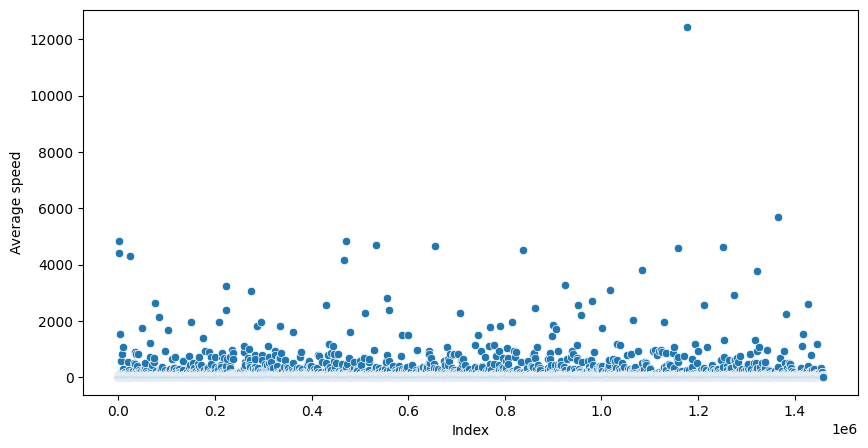

In [ ]:
avg_speed = taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax)
ax.set_xlabel('Index')
ax.set_ylabel('Average speed');

Как раз отсюда мы видим, что у нас есть “поездки-телепортации”, для которых средняя скорость более 1000 км/ч. Даже есть такая, средняя скорость которой составляла более 12000 км/ч!

Давайте условимся, что предельная средняя скорость, которую могут развивать таксисты будет 300 км/ч.


### Задание 2.11.
Найдите поездки, длительность которых превышает 24 часа. И удалите их из набора данных.

а) Сколько выбросов по признаку длительности поездки вам удалось найти?

Найдите поездки, средняя скорость которых по кратчайшему пути превышает 300 км/ч и удалите их из данных.

б) Сколько выбросов по признаку скорости вам удалось найти?

In [ ]:
# ваш код здесь
print(f"Размер данных до удаления выбросов: {taxi_data.shape}")

# а) Выбросы по длительности (> 24 часа = 86400 секунд)
outliers_duration = len(taxi_data[taxi_data['trip_duration'] > 86400])
print(f"а) Количество выбросов по длительности: {outliers_duration}")

# Удаляем выбросы по длительности
taxi_data = taxi_data[taxi_data['trip_duration'] <= 86400]

# б) Выбросы по скорости (> 300 км/ч)
# Сначала убеждаемся, что в total_distance нет пропусков
# Заполняем пропуски в total_distance медианой (если они есть)
if taxi_data['total_distance'].isnull().any():
    median_distance = taxi_data['total_distance'].median()
    taxi_data['total_distance'] = taxi_data['total_distance'].fillna(median_distance)
    print(f"   Заполнено пропусков в total_distance: {taxi_data['total_distance'].isnull().sum()}")

# Рассчитываем среднюю скорость (км/ч)
# total_distance в метрах, trip_duration в секундах
# скорость = расстояние_км / время_часы
avg_speed = (taxi_data['total_distance'] / 1000) / (taxi_data['trip_duration'] / 3600)

# Проверяем, есть ли бесконечные значения (при делении на 0)
avg_speed = avg_speed.replace([np.inf, -np.inf], np.nan)

# Выбросы по скорости (> 300 км/ч)
outliers_speed = len(taxi_data[avg_speed > 300])
print(f"б) Количество выбросов по скорости: {outliers_speed}")

# Удаляем выбросы по скорости
taxi_data = taxi_data[avg_speed <= 300]

print(f"Размер данных после удаления выбросов: {taxi_data.shape}")

Размер данных до удаления выбросов: (1458644, 28)
а) Количество выбросов по длительности: 4
б) Количество выбросов по скорости: 407
Размер данных после удаления выбросов: (1458233, 28)


## 3. Разведывательный анализ данных (EDA)

В этой части нашего проекта мы с вами:
* Исследуем сформированный набор данных;
* Попробуем найти закономерности, позволяющие сформулировать предварительные гипотезы относительно того, какие факторы являются решающими в определении длительности поездки;
* Дополним наш анализ визуализациями, иллюстрирующими; исследование. Постарайтесь оформлять диаграммы с душой, а не «для галочки»: навыки визуализации полученных выводов обязательно пригодятся вам в будущем.


Начинаем с целевого признака. Забегая вперед, скажем, что основной метрикой качества решения поставленной задачи будет RMSLE - Root Mean Squared Log Error, которая вычисляется на основе целевой переменной в логарифмическом масштабе. В таком случае целесообразно сразу логарифмировать признак длительности поездки и рассматривать при анализе логарифм в качестве целевого признака:
$$trip\_duration\_log = log(trip\_duration+1),$$
где под символом log подразумевается натуральный логарифм.


In [ ]:
taxi_data['trip_duration_log'] = np.log(taxi_data['trip_duration']+1)

### Задание 3.1.
Постройте гистограмму и коробчатую диаграмму длительности поездок в логарифмическом масштабе (trip_duration_log).
Исходя из визуализации, сделайте предположение, является ли полученное распределение нормальным?
Проверьте свою гипотезу с помощью теста Д’Агостино при уровне значимости $\alpha=0.05$.

а) Чему равен вычисленный p-value? Ответ округлите до сотых.

б) Является ли распределение длительности поездок в логарифмическом масштабе нормальным?

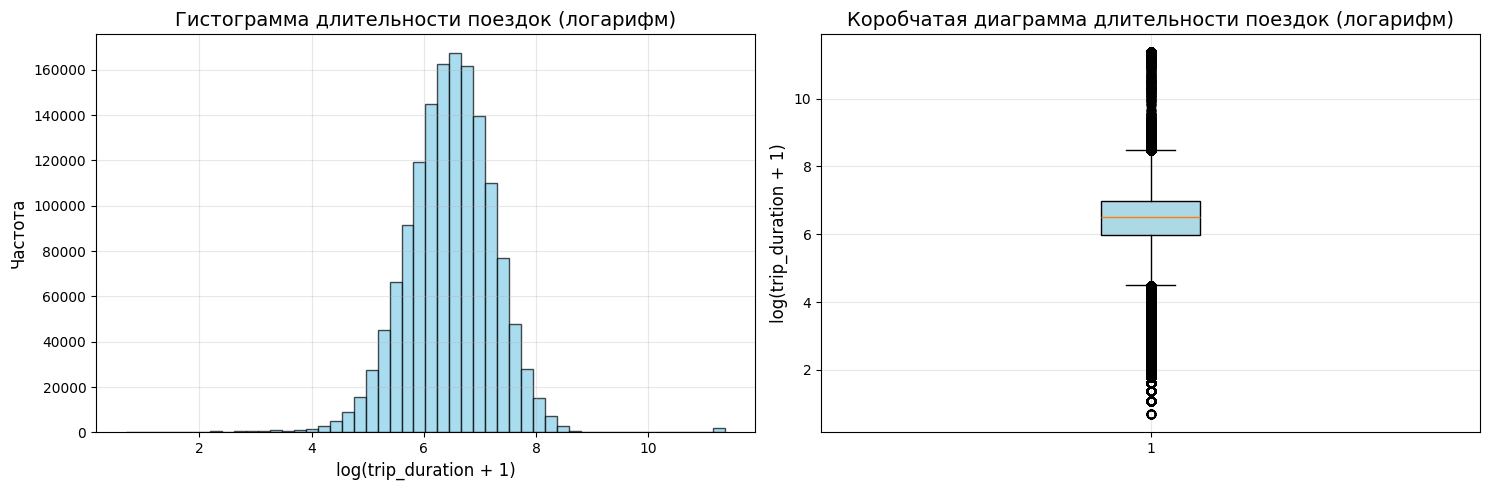

p-value: 0.0000
p-value (округленный до 2 знаков): 0.00


In [ ]:
# ваш код здесь
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
axes[0].hist(taxi_data['trip_duration_log'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Гистограмма длительности поездок (логарифм)', fontsize=14)
axes[0].set_xlabel('log(trip_duration + 1)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Коробчатая диаграмма
axes[1].boxplot(taxi_data['trip_duration_log'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Коробчатая диаграмма длительности поездок (логарифм)', fontsize=14)
axes[1].set_ylabel('log(trip_duration + 1)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

statistic, p_value = stats.normaltest(taxi_data['trip_duration_log'].dropna())
print(f"p-value: {p_value:.4f}")
print(f"p-value (округленный до 2 знаков): {p_value:.2f}")

### Задание 3.2.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от таксопарка (vendor_id).

Сравните два распределения между собой.

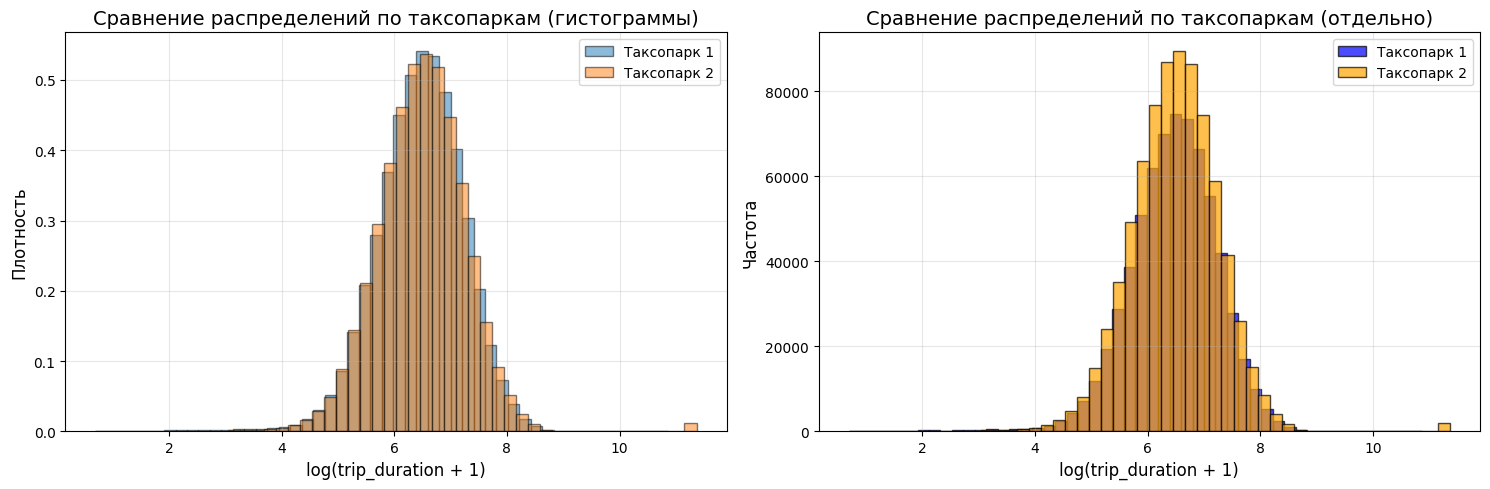

/tmp/ipykernel_3304/329671767.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=taxi_data, x='vendor_id', y='trip_duration_log', ax=axes[0], palette='Set2')


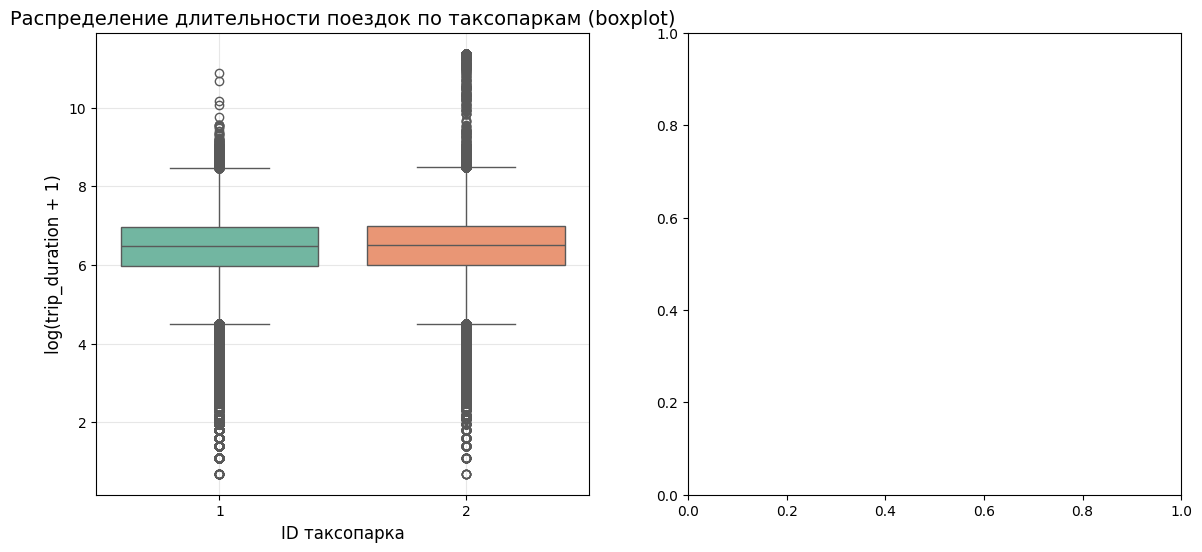

In [ ]:
# ваш код здесь
# Гистограммы для сравнения распределений
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограммы для каждого таксопарка (на одном графике)
ax1 = axes[0]
for vendor in [1, 2]:
    data = taxi_data[taxi_data['vendor_id'] == vendor]['trip_duration_log']
    ax1.hist(data, bins=50, alpha=0.5, label=f'Таксопарк {vendor}', density=True, edgecolor='black')

ax1.set_title('Сравнение распределений по таксопаркам (гистограммы)', fontsize=14)
ax1.set_xlabel('log(trip_duration + 1)', fontsize=12)
ax1.set_ylabel('Плотность', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Отдельные гистограммы для каждого таксопарка
ax2 = axes[1]
# Для таксопарка 1
data_vendor1 = taxi_data[taxi_data['vendor_id'] == 1]['trip_duration_log']
ax2.hist(data_vendor1, bins=50, alpha=0.7, label='Таксопарк 1', color='blue', edgecolor='black')
# Для таксопарка 2
data_vendor2 = taxi_data[taxi_data['vendor_id'] == 2]['trip_duration_log']
ax2.hist(data_vendor2, bins=50, alpha=0.7, label='Таксопарк 2', color='orange', edgecolor='black')

ax2.set_title('Сравнение распределений по таксопаркам (отдельно)', fontsize=14)
ax2.set_xlabel('log(trip_duration + 1)', fontsize=12)
ax2.set_ylabel('Частота', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Коробчатые диаграммы
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(data=taxi_data, x='vendor_id', y='trip_duration_log', ax=axes[0], palette='Set2')
axes[0].set_title('Распределение длительности поездок по таксопаркам (boxplot)', fontsize=14)
axes[0].set_xlabel('ID таксопарка', fontsize=12)
axes[0].set_ylabel('log(trip_duration + 1)', fontsize=12)
axes[0].grid(True, alpha=0.3)


### Задание 3.3.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от признака отправки сообщения поставщику (store_and_fwd_flag).

Сравните два распределения между собой.

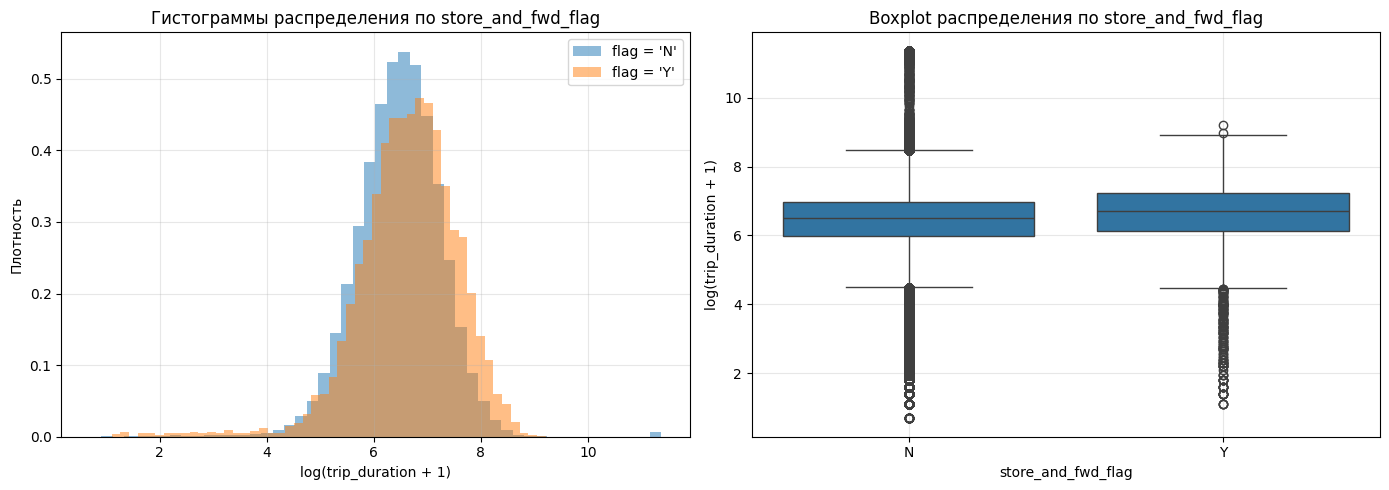

In [ ]:
# ваш код здесь
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for flag in ['N', 'Y']:
    data = taxi_data[taxi_data['store_and_fwd_flag'] == flag]['trip_duration_log']
    axes[0].hist(data, bins=50, alpha=0.5, label=f"flag = '{flag}'", density=True)
axes[0].set_title('Гистограммы распределения по store_and_fwd_flag')
axes[0].set_xlabel('log(trip_duration + 1)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
sns.boxplot(data=taxi_data, x='store_and_fwd_flag', y='trip_duration_log', ax=axes[1])
axes[1].set_title('Boxplot распределения по store_and_fwd_flag')
axes[1].set_xlabel('store_and_fwd_flag')
axes[1].set_ylabel('log(trip_duration + 1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Задание 3.4.
Постройте две визуализации:
* Распределение количества поездок в зависимости от часа дня;
* Зависимость медианной длительности поездки от часа дня.

На основе построенных графиков ответьте на следующие вопросы:

а) В какое время суток такси заказывают реже всего?

б) В какое время суток наблюдается пик медианной длительности поездок?

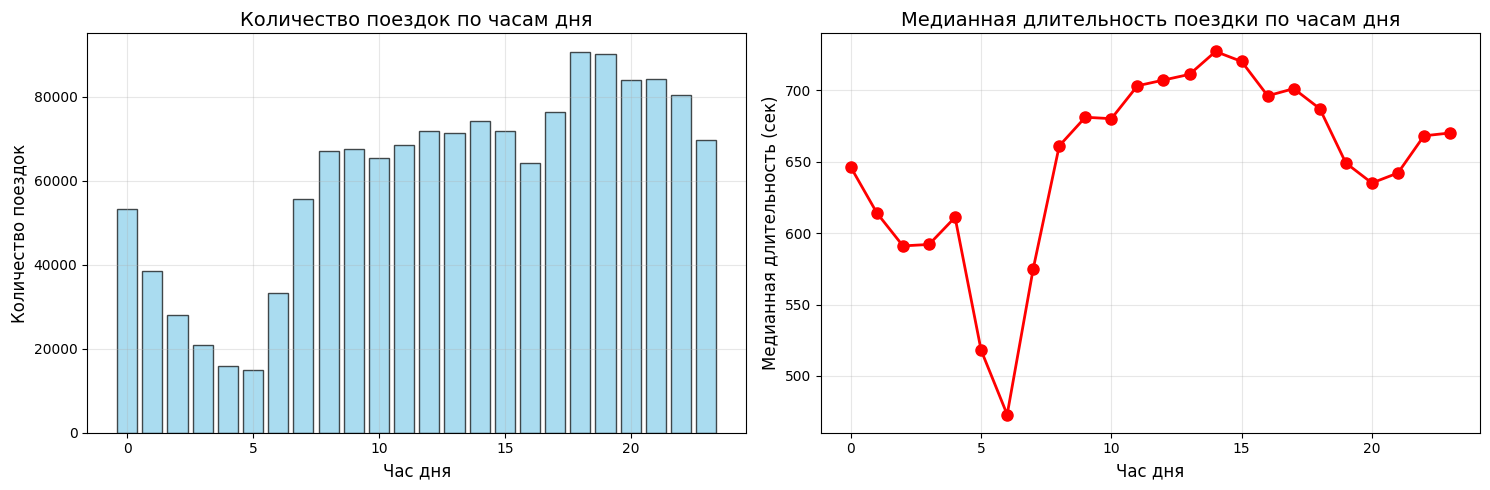

In [ ]:
# ваш код здесь
# Распределение количества поездок по часам
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Количество поездок по часам
hourly_counts = taxi_data.groupby('pickup_hour').size()
axes[0].bar(hourly_counts.index, hourly_counts.values, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Количество поездок по часам дня', fontsize=14)
axes[0].set_xlabel('Час дня', fontsize=12)
axes[0].set_ylabel('Количество поездок', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Медианная длительность поездки по часам
hourly_median = taxi_data.groupby('pickup_hour')['trip_duration'].median()
axes[1].plot(hourly_median.index, hourly_median.values, marker='o', linewidth=2, markersize=8, color='red')
axes[1].set_title('Медианная длительность поездки по часам дня', fontsize=14)
axes[1].set_xlabel('Час дня', fontsize=12)
axes[1].set_ylabel('Медианная длительность (сек)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Задание 3.5.
Постройте две визуализации:
* Распределение количества поездок в зависимости от дня недели;
*  Зависимость медианной длительности поездки от дня недели.

На основе построенных графиков ответьте на следующие вопросы:
а) В какой день недели совершается больше всего поездок?
б) В какой день недели медианная длительность поездок наименьшая?


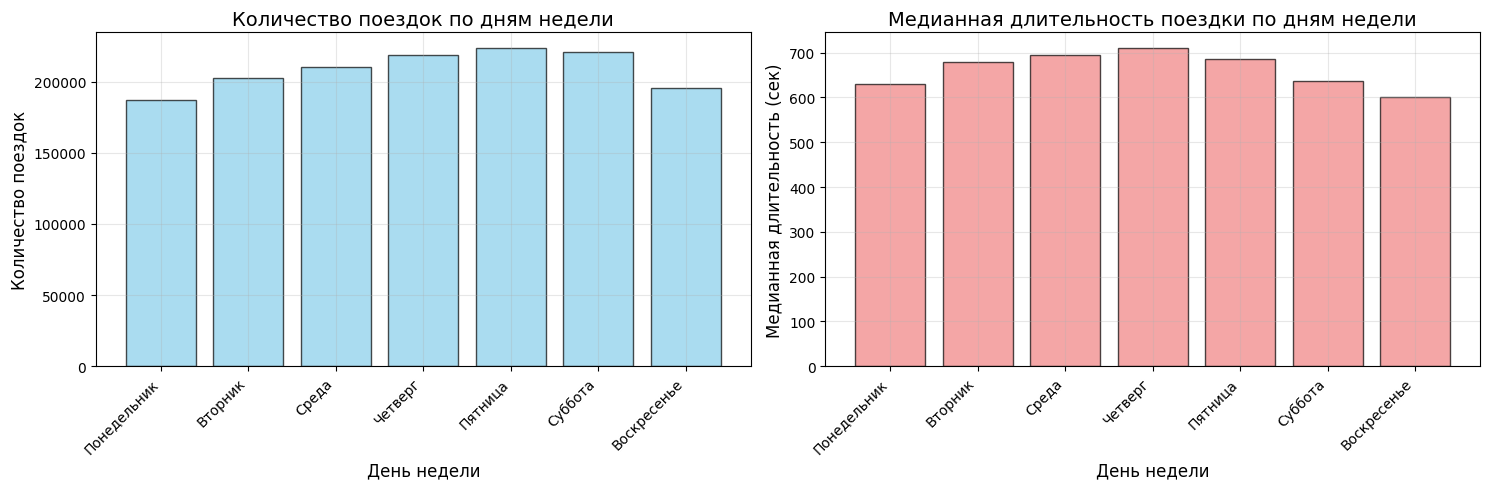

In [ ]:
# ваш код здесь
# Определяем словарь для названий дней недели
days = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

# Словарь для английских названий (для вопросов теста)
days_en = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Распределение количества поездок по дням недели
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Количество поездок по дням недели
daily_counts = taxi_data.groupby('pickup_day_of_week').size()

# Сортируем по дням недели
daily_counts = daily_counts.reindex(range(7))

axes[0].bar(daily_counts.index, daily_counts.values, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Количество поездок по дням недели', fontsize=14)
axes[0].set_xlabel('День недели', fontsize=12)
axes[0].set_ylabel('Количество поездок', fontsize=12)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels([days[i] for i in range(7)], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

# Медианная длительность по дням недели
daily_median = taxi_data.groupby('pickup_day_of_week')['trip_duration'].median()
daily_median = daily_median.reindex(range(7))

axes[1].bar(daily_median.index, daily_median.values, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Медианная длительность поездки по дням недели', fontsize=14)
axes[1].set_xlabel('День недели', fontsize=12)
axes[1].set_ylabel('Медианная длительность (сек)', fontsize=12)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([days[i] for i in range(7)], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 3.6.
Посмотрим на обе временные характеристики одновременно.

Постройте сводную таблицу, по строкам которой отложены часы (pickup_hour), по столбцам - дни недели (pickup_day_of_week), а в ячейках - медианная длительность поездки (trip_duration).

Визуализируйте полученную сводную таблицу с помощью тепловой карты (рекомендуемая палитра - coolwarm).

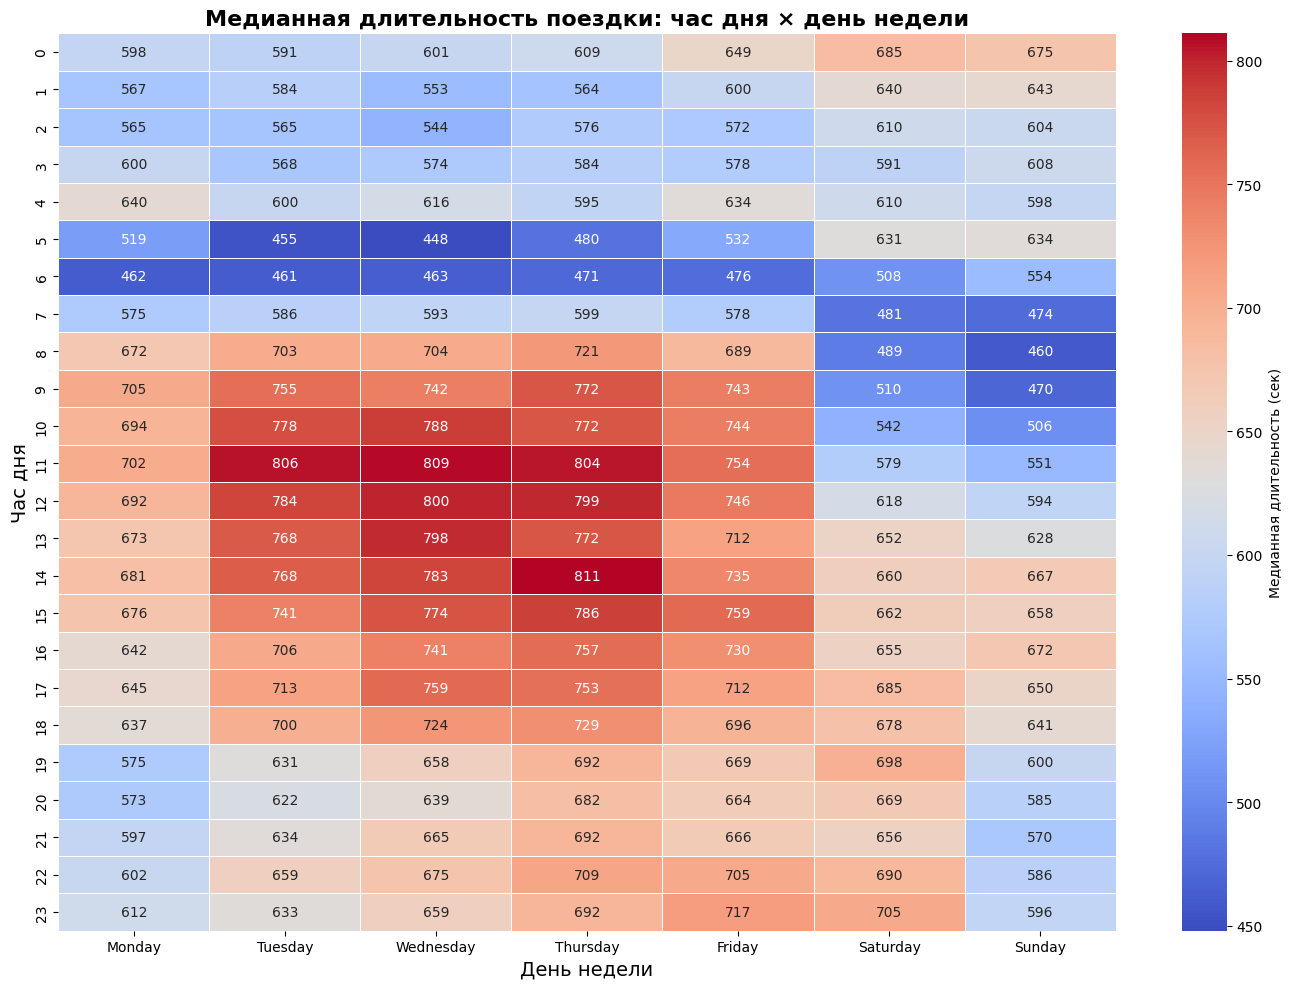

In [ ]:
# ваш код здесь
# Cоздаем сводную таблицу
pivot_table = taxi_data.pivot_table(
    values='trip_duration',
    index='pickup_hour',
    columns='pickup_day_of_week',
    aggfunc='median'
)

# Переименовываем столбцы для лучшей читаемости
pivot_table.columns = [days_en[i] for i in pivot_table.columns]
# Тепловая карта
plt.figure(figsize=(14, 10))

# Создаем тепловую карту с палитрой coolwarm
sns.heatmap(
    pivot_table,
    cmap='coolwarm',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Медианная длительность (сек)'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Медианная длительность поездки: час дня × день недели', fontsize=16, fontweight='bold')
plt.xlabel('День недели', fontsize=14)
plt.ylabel('Час дня', fontsize=14)

plt.tight_layout()
plt.show()

### Задание 3.7.
Постройте две диаграммы рассеяния (scatter-диаграммы):
* первая должна иллюстрировать географическое расположение точек начала поездок (pickup_longitude, pickup_latitude)
* вторая должна географическое расположение точек завершения поездок (dropoff_longitude, dropoff_latitude).

Для этого на диаграммах по оси абсцисс отложите широту (longitude), а по оси ординат - долготу (latitude).
Включите в визуализацию только те точки, которые находятся в пределах Нью-Йорка - добавьте следующие ограничения на границы осей абсцисс и ординат:

city_long_border = (-74.03, -73.75)

city_lat_border = (40.63, 40.85)

Добавьте на диаграммы расцветку по десяти географическим кластерам (geo_cluster), которые мы сгенерировали ранее.

**Рекомендация:** для наглядности уменьшите размер точек на диаграмме рассеяния.  


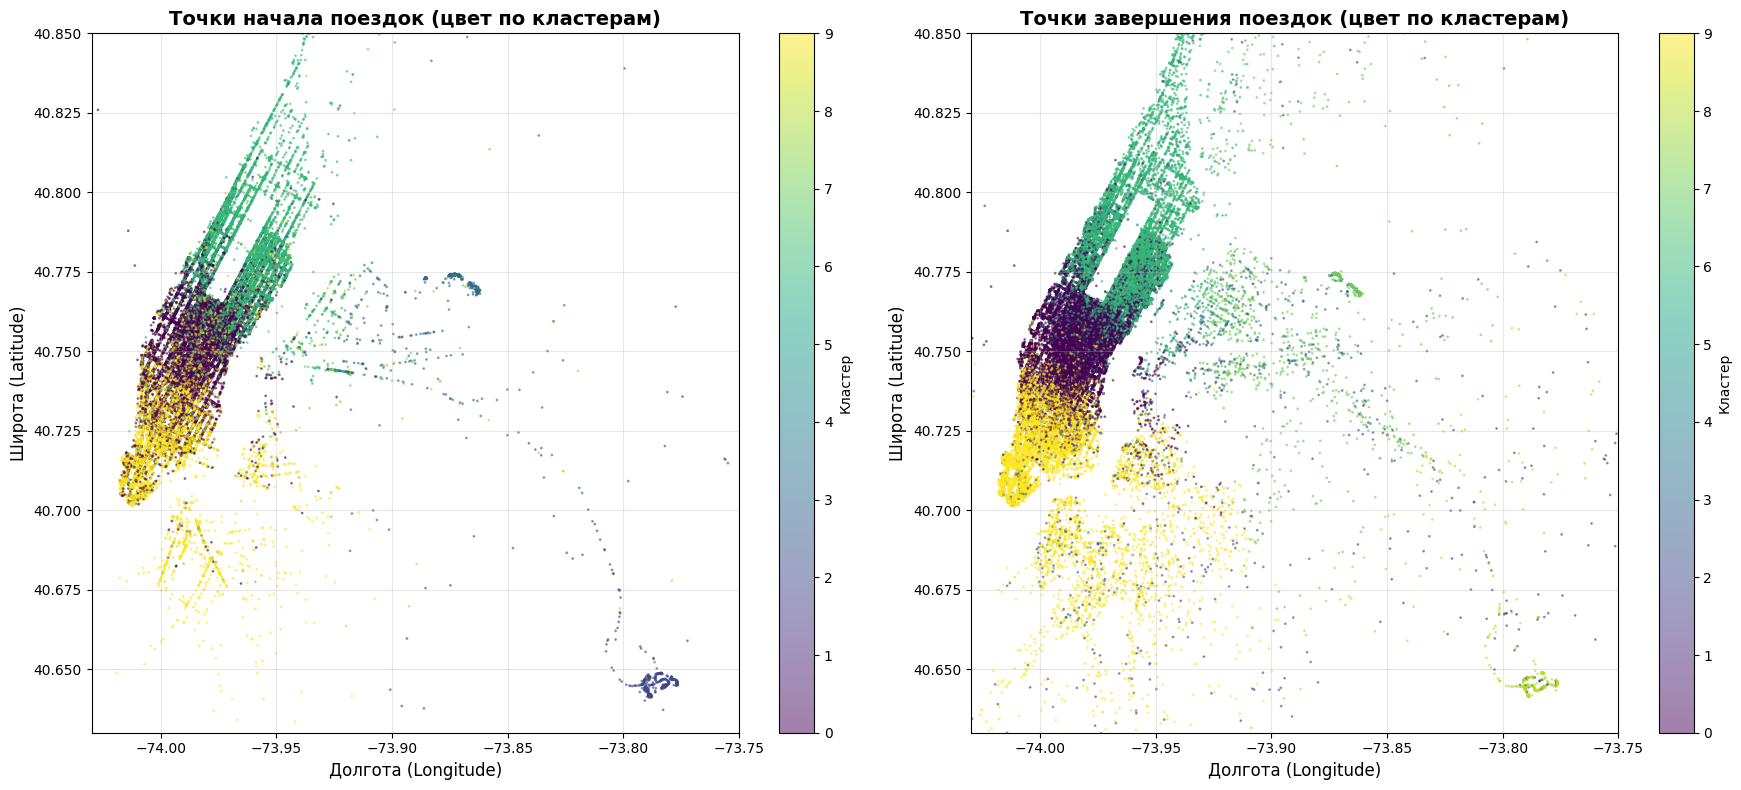


Все кластеры в данных: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]
Кластеры в пределах Нью-Йорка: [np.int32(0), np.int32(2), np.int32(3), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]
Кластеры за пределами Нью-Йорка: [np.int32(1), np.int32(4), np.int32(5)]


In [ ]:
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)

# ваш код здесь

# Фильтруем данные по границам города
city_data = taxi_data[
    (taxi_data['pickup_longitude'] >= city_long_border[0]) &
    (taxi_data['pickup_longitude'] <= city_long_border[1]) &
    (taxi_data['pickup_latitude'] >= city_lat_border[0]) &
    (taxi_data['pickup_latitude'] <= city_lat_border[1])
]

# Cоздаем выборку для визуализации (чтобы не перегружать график)
sample_size = 50000
sample_data = city_data.sample(n=min(sample_size, len(city_data)), random_state=42)

# Построение диаграмм рассеяния
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Точки начала поездок
scatter1 = axes[0].scatter(
    sample_data['pickup_longitude'],
    sample_data['pickup_latitude'],
    c=sample_data['geo_cluster'],
    cmap='viridis',
    alpha=0.5,
    s=1
)
axes[0].set_title('Точки начала поездок (цвет по кластерам)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Долгота (Longitude)', fontsize=12)
axes[0].set_ylabel('Широта (Latitude)', fontsize=12)
axes[0].set_xlim(city_long_border)
axes[0].set_ylim(city_lat_border)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Кластер', ticks=range(10))

# Точки завершения поездок
scatter2 = axes[1].scatter(
    sample_data['dropoff_longitude'],
    sample_data['dropoff_latitude'],
    c=sample_data['geo_cluster'],
    cmap='viridis',
    alpha=0.5,
    s=1
)
axes[1].set_title('Точки завершения поездок (цвет по кластерам)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Долгота (Longitude)', fontsize=12)
axes[1].set_ylabel('Широта (Latitude)', fontsize=12)
axes[1].set_xlim(city_long_border)
axes[1].set_ylim(city_lat_border)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Кластер', ticks=range(10))

plt.tight_layout()
plt.show()

# Находим все кластеры, которые есть в данных
all_clusters_present = sorted(taxi_data['geo_cluster'].unique())
print(f"\nВсе кластеры в данных: {all_clusters_present}")

# Находим кластеры в пределах Нью-Йорка
clusters_in_city = sorted(city_data['geo_cluster'].unique())
print(f"Кластеры в пределах Нью-Йорка: {clusters_in_city}")

# Находим кластеры за пределами Нью-Йорка
clusters_outside = sorted(set(all_clusters_present) - set(clusters_in_city))
print(f"Кластеры за пределами Нью-Йорка: {clusters_outside}")

## 4. Отбор и преобразование признаков

Перед тем как перейти к построению модели, осталось сделать ещё несколько шагов.
* Следует помнить, что многие алгоритмы машинного обучения не могут обрабатывать категориальные признаки в их обычном виде. Поэтому нам необходимо их закодировать;
* Надо отобрать признаки, которые мы будем использовать для обучения модели;
*  Необходимо масштабировать и трансформировать некоторые признаки для того, чтобы улучшить сходимость моделей, в основе которых лежат численные методы.


In [ ]:
# Удаляем лишние столбцы 'date' и 'hour'
# Эти столбцы могли появиться после объединения с weather_data
columns_to_drop = ['date', 'hour']
taxi_data = taxi_data.drop(columns=columns_to_drop, errors='ignore')

# Переименовываем 'wind speed' в 'wind_speed' для соответствия
if 'wind speed' in taxi_data.columns:
    taxi_data = taxi_data.rename(columns={'wind speed': 'wind_speed'})

In [ ]:
print('Shape of data: {}'.format(taxi_data.shape))
print('Columns: {}'.format(taxi_data.columns))

Shape of data: (1458233, 27)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind_speed', 'precip', 'events',
       'trip_duration_log'],
      dtype='object')


Для удобства работы сделаем копию исходной таблицы с поездками:

In [ ]:
train_data = taxi_data.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind_speed,precip,events,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,5.0,1.498521,99.970196,6,4.4,8.0,27.8,0.3,None,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6.0,1.805507,-117.153768,9,28.9,16.1,7.4,0.0,None,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,16.0,6.385098,-159.680165,9,-6.7,16.1,24.1,0.0,None,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,4.0,1.485498,-172.737700,9,7.2,16.1,25.9,0.0,None,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5.0,1.188588,179.473585,6,9.4,16.1,9.3,0.0,None,6.077642


### Задание 4.1.
Сразу позаботимся об очевидных неинформативных и избыточных признаках.

а) Какой из признаков является уникальным для каждой поездки и не несет полезной информации в определении ее продолжительности?

б) Утечка данных (data leak) - это…

в) Подумайте, наличие какого из признаков в обучающем наборе данных создает утечку данных?

г) Исключите выбранные в пунктах а) и в) признаки из исходной таблицы с данными. Сколько столбцов в таблице у вас осталось?


In [ ]:
# ваш код здесь
# Удаляем признаки id и dropoff_datetime
train_data = train_data.drop(['id', 'dropoff_datetime'], axis=1)

print(f"Количество столбцов после удаления: {len(train_data.columns)}")


Количество столбцов после удаления: 25


Ранее мы извлекли всю необходимую для нас информацию из даты начала поездки, теперь мы можем избавиться от этих признаков, так как они нам больше не понадобятся:


In [ ]:
drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


### Задание 4.2.

Закодируйте признак vendor_id в таблице train_data таким образом, чтобы он был равен 0, если идентификатор таксопарка равен 1, и 1 — в противном случае.

Закодируйте признак store_and_fwd_flag в таблице train_data таким образом, чтобы он был равен 0, если флаг выставлен в значение 'N', и 1 — в противном случае.

а) Рассчитайте среднее по закодированному столбцу vendor_id. Ответ приведите с точностью до сотых.

б) Рассчитайте среднее по закодированному столбцу store_and_fwd_flag. Ответ приведите с точностью до тысячных.



In [ ]:
# ваш код здесь
# Кодируем vendor_id
# 0 если vendor_id = 1, иначе 1
train_data['vendor_id'] = train_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)

# Кодируем store_and_fwd_flag
# 0 если 'N', иначе 1
train_data['store_and_fwd_flag'] = train_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)

# Среднее по vendor_id
vendor_mean = train_data['vendor_id'].mean()
print(f"\n1. Среднее по vendor_id: {vendor_mean:.2f}")

# Среднее по store_and_fwd_flag
store_mean = train_data['store_and_fwd_flag'].mean()
print(f"2. Среднее по store_and_fwd_flag: {store_mean:.3f}")


1. Среднее по vendor_id: 0.53
2. Среднее по store_and_fwd_flag: 0.006


### Задание 4.3.
Создайте таблицу data_onehot из закодированных однократным кодированием признаков pickup_day_of_week, geo_cluster и events в таблице train_data с помощью OneHotEncoder из библиотеки sklearn. Параметр drop выставите в значение 'first', чтобы удалять первый бинарный столбец, тем самым не создавая излишних признаков.

В параметре handle_unknown установите значение 'ignore'. Это позволит коду отработать без ошибок в случае появления в тестовой выборке значений, отсутствующих в обучающей выборке.

В результате работы OneHotEncoder вы получите безымянный numpy-массив, который нам будет необходимо преобразовать обратно в DataFrame, для более удобной работы в дальнейшем. Чтобы получить имена закодированных столбцов у объекта типа OneHotEncoder есть специальный метод get_feature_names_out(). Он возвращает список новых закодированных имен столбцов в формате <оригинальное имя столбца>_<имя категории>.

Пример использования:

``` python
# Объявляем кодировщик
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
# Получаем закодированные имена столбцов
column_names = one_hot_encoder.get_feature_names_out()
# Составляем DataFrame из закодированных признаков
data_onehot = pd.DataFrame(data_onehot, columns=column_names)
```

В этом псевдокоде:
* one_hot_encoder - объект класса OneHotEncoder
* data_onehot - numpy-массив, полученный в результате трансформации кодировщиком

В результате выполнения задания у вас должен быть образован DataFrame `data_onehot`, который содержит кодированные категориальные признаки pickup_day_of_week, geo_cluster и events.


Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования?


In [ ]:
# ваш код здесь
from sklearn.preprocessing import OneHotEncoder
# Определяем столбцы для кодирования
columns_to_encode = ['pickup_day_of_week', 'geo_cluster', 'events']
# Создаем и обучаем кодировщик
one_hot_encoder = OneHotEncoder(
    drop='first',           # удаляем первый бинарный столбец
    handle_unknown='ignore', # игнорируем неизвестные значения
    sparse_output=False     # возвращаем плотный массив
)

# Применяем кодирование
data_onehot_array = one_hot_encoder.fit_transform(train_data[columns_to_encode])

# Получаем имена столбцов
column_names = one_hot_encoder.get_feature_names_out(columns_to_encode)

# Создаем DataFrame
data_onehot = pd.DataFrame(data_onehot_array, columns=column_names)

print(f"Количество бинарных столбцов: {data_onehot.shape[1]}")

Количество бинарных столбцов: 18


Добавим полученную таблицу с закодированными признаками:

In [ ]:
columns_to_change = ['pickup_day_of_week', 'geo_cluster', 'events']

train_data = pd.concat(
    [train_data.reset_index(drop=True).drop(columns_to_change, axis=1), data_onehot],
    axis=1
)
print('Shape of data: {}'.format(train_data.shape))

Shape of data: (1458233, 38)


Теперь, когда категориальные признаки предобработаны, сформируем матрицу наблюдений X, вектор целевой переменной y и его логарифм y_log. В матрицу наблюдений войдут все столбцы из таблицы с поездками за исключением целевого признака trip_duration и его логарифмированной версии trip_duration_log:


In [ ]:
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

Все наши модели мы будем обучать на логарифмированной версии y_log.

Выбранный тип валидации - hold-out. Разобьем выборку на обучающую и валидационную в соотношении 67/33:

In [ ]:
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log,
    test_size=0.33,
    random_state=42
)

На данный момент у нас достаточно много признаков: скорее всего, не все из них будут важны. Давайте оставим лишь те, которые сильнее всего связаны с целевой переменной и точно будут вносить вклад в повышение качества модели.


### Задание 4.4.
С помощью SelectKBest отберите 25 признаков, наилучшим образом подходящих для предсказания целевой переменной в логарифмическом масштабе. Отбор реализуйте по обучающей выборке, используя параметр score_func = f_regression.

Укажите признаки, которые вошли в список отобранных


In [ ]:
# ваш код здесь
from sklearn.feature_selection import SelectKBest, f_regression
# Создаем и применяем SelectKBest
selector = SelectKBest(score_func=f_regression, k=25)
selector.fit(X_train, y_train_log)

# Получаем индексы отобранных признаков
selected_indices = selector.get_support(indices=True)
best_features = X_train.columns[selected_indices].tolist()

# Проверяем, какие из предложенных признаков вошли в список

candidate_features = {
    'A': 'vendor_id',
    'B': 'passenger_count',
    'C': 'number_of_steps',
    'D': 'temperature',
    'E': 'events_None',
    'F': 'visibility',
    'G': 'wind speed'
}

print("Какие из предложенных признаков вошли в отбор:")
for letter, feature in candidate_features.items():
    if feature in best_features:
        print(f"  {letter}. {feature} ВКЛЮЧЕН")
    else:
        print(f"  {letter}. {feature} НЕ ВКЛЮЧЕН")
# Сокращаем выборки до отобранных признаков
X_train = X_train[best_features]
X_valid = X_valid[best_features]


Какие из предложенных признаков вошли в отбор:
  A. vendor_id ВКЛЮЧЕН
  B. passenger_count ВКЛЮЧЕН
  C. number_of_steps ВКЛЮЧЕН
  D. temperature ВКЛЮЧЕН
  E. events_None НЕ ВКЛЮЧЕН
  F. visibility НЕ ВКЛЮЧЕН
  G. wind speed НЕ ВКЛЮЧЕН


Так как мы будем использовать различные модели, в том числе внутри которых заложены численные методы оптимизации, то давайте заранее позаботимся о масштабировании факторов.


### Задание 4.5.
Нормализуйте предикторы в обучающей и валидационной выборках с помощью MinMaxScaler из библиотеки sklearn. Помните, что обучение нормализатора производится на обучающей выборке, а трансформация на обучающей и валидационной!

Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из валидационной выборки. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
from sklearn.preprocessing import MinMaxScaler
# Создаем и обучаем нормализатор на обучающей выборке
scaler = MinMaxScaler()
scaler.fit(X_train)
# Применяем нормализацию к обучающей и валидационной выборкам
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)
# Рассчитываем среднее арифметическое для первого предиктора
# Первый предиктор в X_valid_scaled - это первый столбец
first_feature_mean = X_valid_scaled.iloc[:, 0].mean()
print(f"Первый предиктор в валидационной выборке: '{X_valid_scaled.columns[0]}'")
print(f"\nСреднее арифметическое: {first_feature_mean:.2f}")


Первый предиктор в валидационной выборке: 'vendor_id'

Среднее арифметическое: 0.54


## 5. Решение задачи регрессии: линейная регрессия и деревья решений

Определим метрику, по которой мы будем измерять качество наших моделей. Мы будем следовать канонам исходного соревнования на Kaggle и в качестве метрики использовать RMSLE (Root Mean Squared Log Error), которая вычисляется как:
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$
где:
* $y_i$ - истинная длительность i-ой поездки на такси (trip_duration)
* $\hat{y_i}$- предсказанная моделью длительность i-ой поездки на такси

Заметим, что логарифмирование целевого признака мы уже провели заранее, поэтому нам будет достаточно вычислить метрику RMSE для модели, обученной прогнозировать длительность поездки такси в логарифмическом масштабе:
$$z_i=log(y_i+1),$$
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$$



### Задание 5.1.
Постройте модель линейной регрессии на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 977016 entries, 0 to 977015
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vendor_id             977016 non-null  float64
 1   passenger_count       977016 non-null  float64
 2   pickup_longitude      977016 non-null  float64
 3   pickup_latitude       977016 non-null  float64
 4   dropoff_longitude     977016 non-null  float64
 5   dropoff_latitude      977016 non-null  float64
 6   store_and_fwd_flag    977016 non-null  float64
 7   pickup_hour           977016 non-null  float64
 8   pickup_holiday        977016 non-null  float64
 9   total_distance        977016 non-null  float64
 10  total_travel_time     977016 non-null  float64
 11  number_of_steps       977016 non-null  float64
 12  haversine_distance    977016 non-null  float64
 13  temperature           977016 non-null  float64
 14  pickup_day_of_week_1  977016 non-null  float64
 15  

In [ ]:
X_valid_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481217 entries, 0 to 481216
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vendor_id             481217 non-null  float64
 1   passenger_count       481217 non-null  float64
 2   pickup_longitude      481217 non-null  float64
 3   pickup_latitude       481217 non-null  float64
 4   dropoff_longitude     481217 non-null  float64
 5   dropoff_latitude      481217 non-null  float64
 6   store_and_fwd_flag    481217 non-null  float64
 7   pickup_hour           481217 non-null  float64
 8   pickup_holiday        481217 non-null  float64
 9   total_distance        481217 non-null  float64
 10  total_travel_time     481217 non-null  float64
 11  number_of_steps       481217 non-null  float64
 12  haversine_distance    481217 non-null  float64
 13  temperature           481217 non-null  float64
 14  pickup_day_of_week_1  481217 non-null  float64
 15  

In [ ]:
# ваш код здесь
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# Создаем и обучаем модель линейной регрессии
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)
# Делаем предсказания
y_train_pred_log = lr_model.predict(X_train_scaled)
y_valid_pred_log = lr_model.predict(X_valid_scaled)
# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
# Рассчитываем RMSLE
train_rmsle = rmsle(y_train_log, y_train_pred_log)
valid_rmsle = rmsle(y_valid_log, y_valid_pred_log)
print(f"RMSLE на обучающей выборке: {train_rmsle:.2f}")
print(f"RMSLE на валидационной выборке: {valid_rmsle:.2f}")


RMSLE на обучающей выборке: 0.54
RMSLE на валидационной выборке: 0.54


### Задание 5.2.
Сгенерируйте полиномиальные признаки 2-ой степени с помощью PolynomialFeatures из библиотеки sklearn. Параметр include_bias выставите в значение False.

Постройте модель полиномиальной регрессии 2-ой степени на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [ ]:
# ваш код здесь
#from sklearn.preprocessing import PolynomialFeatures
# Создаем генератор полиномиальных признаков
#poly = PolynomialFeatures(degree=2, include_bias=False)

# Генерируем полиномиальные признаки
#X_train_poly = poly.fit_transform(X_train_scaled)
#X_valid_poly = poly.transform(X_valid_scaled)

# Создаем и обучаем модель линейной регрессии на полиномиальных признаках
#poly_model = LinearRegression()
#poly_model.fit(X_train_poly, y_train_log)

# Делаем предсказания
#y_train_pred_log_poly = poly_model.predict(X_train_poly)
#y_valid_pred_log_poly = poly_model.predict(X_valid_poly)

# Функция для расчета RMSLE
#def rmsle(y_true, y_pred):
    #return np.sqrt(mean_squared_error(y_true, y_pred))

# Рассчитываем RMSLE
#train_rmsle_poly = rmsle(y_train_log, y_train_pred_log_poly)
#valid_rmsle_poly = rmsle(y_valid_log, y_valid_pred_log_poly)

#print(f"RMSLE на обучающей выборке: {train_rmsle_poly:.2f}")
#print(f"RMSLE на валидационной выборке: {valid_rmsle_poly:.2f}")

### Задание 5.3.
Постройте модель полиномиальной регрессии 2-ой степени с L2-регуляризацией (регуляризация по Тихонову) на обучающей выборке  (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Коэффициент регуляризации $\alpha$ установите равным 1, остальные параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
# Создаем и обучаем модель Ridge с alpha=1
#ridge_model = Ridge(alpha=1.0)
#ridge_model.fit(X_train_poly, y_train_log)

# Делаем предсказания
#y_train_pred_log_ridge = ridge_model.predict(X_train_poly)
#y_valid_pred_log_ridge = ridge_model.predict(X_valid_poly)

# Функция для расчета RMSLE
#def rmsle(y_true, y_pred):
    #return np.sqrt(mean_squared_error(y_true, y_pred))

# Рассчитываем RMSLE
#train_rmsle_ridge = rmsle(y_train_log, y_train_pred_log_ridge)
#valid_rmsle_ridge = rmsle(y_valid_log, y_valid_pred_log_ridge)

#print(f"RMSLE на обучающей выборке: {train_rmsle_ridge:.2f}")
#print(f"RMSLE на валидационной выборке: {valid_rmsle_ridge:.2f}")

### Задание 5.4.
Постройте модель дерева решений (DecisionTreeRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [ ]:
# ваш код здесь
from sklearn.tree import DecisionTreeRegressor
# Создаем и обучаем модель дерева решений
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train_log)

# Делаем предсказания
y_train_pred_log_dt = dt_model.predict(X_train_scaled)
y_valid_pred_log_dt = dt_model.predict(X_valid_scaled)

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Рассчитываем RMSLE
train_rmsle_dt = rmsle(y_train_log, y_train_pred_log_dt)
valid_rmsle_dt = rmsle(y_valid_log, y_valid_pred_log_dt)

print(f"RMSLE на обучающей выборке: {train_rmsle_dt:.2f}")
print(f"RMSLE на валидационной выборке: {valid_rmsle_dt:.2f}")

RMSLE на обучающей выборке: 0.00
RMSLE на валидационной выборке: 0.57


### Задание 5.5.
Переберите все возможные варианты глубины дерева решений в диапазоне от 7 до 20:

max_depths = range(7, 20)

Параметр random_state задайте равным 42.

Постройте линейные графики изменения метрики RMSE на тренировочной и валидационной выборках в зависимости от значения параметра глубины дерева решений.

а) Найдите оптимальное значение максимальной глубины дерева, для которой будет наблюдаться минимальное значение RMSLE на обучающей выборке, но при этом еще не будет наблюдаться переобучение (валидационная кривая еще не начинает возрастать).

б) Чему равно значение метрик RMSLE на тренировочной и валидационной выборках для дерева решений с выбранной оптимальной глубиной? Ответ округлите до сотых.


In [ ]:
# ваш код здесь
# Определяем диапазон глубин
max_depths = range(7, 20)

# Списки для хранения результатов
train_rmsle_list = []
valid_rmsle_list = []
depths_list = []


# Перебираем все глубины
for depth in max_depths:

    # Создаем и обучаем модель
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train_scaled, y_train_log)

    # Делаем предсказания
    y_train_pred_log = dt_model.predict(X_train_scaled)
    y_valid_pred_log = dt_model.predict(X_valid_scaled)

    # Рассчитываем RMSLE
    train_rmsle = np.sqrt(mean_squared_error(y_train_log, y_train_pred_log))
    valid_rmsle = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_log))

    train_rmsle_list.append(train_rmsle)
    valid_rmsle_list.append(valid_rmsle)
    depths_list.append(depth)

    print(f"Train: {train_rmsle:.4f}, Valid: {valid_rmsle:.4f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'depth': depths_list,
    'train_rmsle': train_rmsle_list,
    'valid_rmsle': valid_rmsle_list
})
# Находим оптимальную глубину (где valid минимальна)
optimal_depth = depths_list[np.argmin(valid_rmsle_list)]
train_at_optimal = train_rmsle_list[np.argmin(valid_rmsle_list)]
valid_at_optimal = valid_rmsle_list[np.argmin(valid_rmsle_list)]

print(f"\nОптимальная глубина (min valid RMSLE): {optimal_depth}")
print(f"Train RMSLE: {train_at_optimal:.2f}")
print(f"Valid RMSLE: {valid_at_optimal:.2f}")

Train: 0.4448, Valid: 0.4471
Train: 0.4370, Valid: 0.4408
Train: 0.4299, Valid: 0.4356
Train: 0.4224, Valid: 0.4313
Train: 0.4145, Valid: 0.4303
Train: 0.4059, Valid: 0.4296
Train: 0.3955, Valid: 0.4321
Train: 0.3837, Valid: 0.4376
Train: 0.3704, Valid: 0.4451
Train: 0.3557, Valid: 0.4525
Train: 0.3394, Valid: 0.4625
Train: 0.3220, Valid: 0.4724
Train: 0.3034, Valid: 0.4838

Оптимальная глубина (min valid RMSLE): 12
Train RMSLE: 0.41
Valid RMSLE: 0.43


## 6. Решение задачи регрессии: ансамблевые методы и построение прогноза

Переходим к тяжелой артиллерии: ансамблевым алгоритмам.

### Задание 6.1.

Постройте модель случайного леса на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* n_estimators=200,
* max_depth=12,
* criterion='squared_error',
* min_samples_split=20,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
from sklearn.ensemble import RandomForestRegressor
# Создаем и обучаем модель случайного леса
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    criterion='squared_error',
    min_samples_split=20,
    random_state=42,
    n_jobs=-1  # используем все ядра
)
rf_model.fit(X_train_scaled, y_train_log)
# Делаем предсказания
y_train_pred_log_rf = rf_model.predict(X_train_scaled)
y_valid_pred_log_rf = rf_model.predict(X_valid_scaled)

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Рассчитываем RMSLE
train_rmsle_rf = rmsle(y_train_log, y_train_pred_log_rf)
valid_rmsle_rf = rmsle(y_valid_log, y_valid_pred_log_rf)
print(f"RMSLE на обучающей выборке: {train_rmsle_rf:.2f}")
print(f"RMSLE на валидационной выборке: {valid_rmsle_rf:.2f}")

RMSLE на обучающей выборке: 0.40
RMSLE на валидационной выборке: 0.41


### Задание 6.2.
Постройте модель градиентного бустинга над деревьями решений (GradientBoostingRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* learning_rate=0.5,
* n_estimators=100,
* max_depth=6,
* min_samples_split=30,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
from sklearn.ensemble import GradientBoostingRegressor
# Создаем и обучаем модель градиентного бустинга
gb_model = GradientBoostingRegressor(
    learning_rate=0.5,
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train_log)

#Делаем предсказания
y_train_pred_log_gb = gb_model.predict(X_train_scaled)
y_valid_pred_log_gb = gb_model.predict(X_valid_scaled)

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Рассчитываем RMSLE
train_rmsle_gb = rmsle(y_train_log, y_train_pred_log_gb)
valid_rmsle_gb = rmsle(y_valid_log, y_valid_pred_log_gb)
print(f"RMSLE на обучающей выборке: {train_rmsle_gb:.2f}")
print(f"RMSLE на валидационной выборке: {valid_rmsle_gb:.2f}")

RMSLE на обучающей выборке: 0.37
RMSLE на валидационной выборке: 0.39


### Задание 6.3.
Какая из построенных вами моделей показала наилучший результат (наименьшее значение RMSLE на валидационной выборке)?
* Линейная регрессия
* Полиномиальная регрессия 2ой степени
* Дерево решений
* Случайный лес
* Градиентный бустинг над деревьями решений


### Задание 6.4.
Постройте столбчатую диаграмму коэффициентов значимости каждого из факторов.

Укажите топ-3 наиболее значимых для предсказания целевого признака - длительности поездки в логарифмическом масштабе - факторов.


10. total_distance: 0.6281
11. total_travel_time: 0.1869
 8. pickup_hour: 0.0591
 6. dropoff_latitude: 0.0296
13. haversine_distance: 0.0264
 5. dropoff_longitude: 0.0150
 3. pickup_longitude: 0.0108
 4. pickup_latitude: 0.0108
20. pickup_day_of_week_6: 0.0076
12. number_of_steps: 0.0057


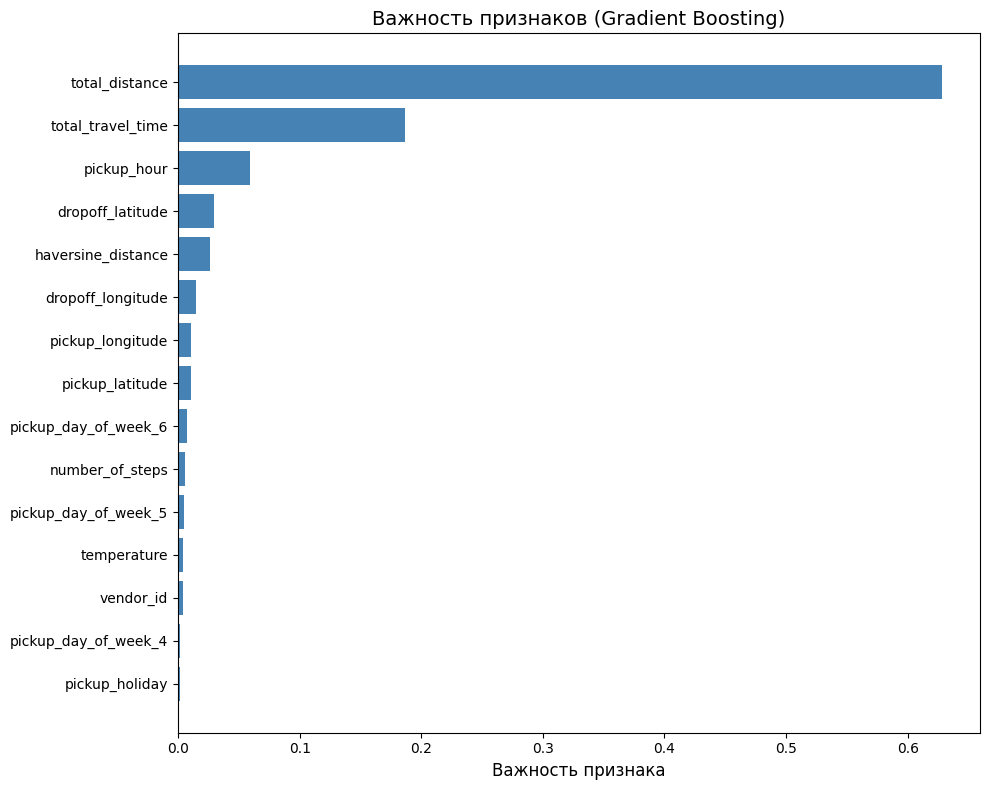

In [ ]:
# ваш код здесь
# Используем лучшую модель (Gradient Boosting)
if 'gb_model' in locals():
    model = gb_model
    model_name = "Gradient Boosting"
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Топ-3
top3 = feature_importance.head(3)

for i, row in feature_importance.head(10).iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")
# Столбчатая диаграмма
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['feature'],
         feature_importance.head(15)['importance'],
         color='steelblue')
plt.xlabel('Важность признака', fontsize=12)
plt.title(f'Важность признаков ({model_name})', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Задание 6.5.
Для лучшей из построенных моделей рассчитайте медианную абсолютную ошибку (MeAE - в sklearn функция median_absolute_error) предсказания длительности поездки такси на валидационной выборке:
$$ MeAE = median(|y_i-\hat{y_i}|)$$

Значение метрики MeAE переведите в минуты и округлите до десятых.


In [ ]:
# ваш код здесь
from sklearn.metrics import median_absolute_error
# Используем лучшую модель (Gradient Boosting)
if 'gb_model' in locals():
    model = gb_model
    model_name = "Gradient Boosting"
# Делаем предсказания на валидационной выборке
y_valid_pred_log = model.predict(X_valid_scaled)

# Переводим из логарифмического масштаба в реальный
y_valid_true = np.exp(y_valid_log) - 1
y_valid_pred = np.exp(y_valid_pred_log) - 1

# Рассчитываем MeAE в секундах
mae_seconds = median_absolute_error(y_valid_true, y_valid_pred)

# Переводим в минуты
mae_minutes = mae_seconds / 60

print(f"В минутах: {mae_minutes:.1f} мин")

В минутах: 1.8 мин


Финальный шаг - сделать submit -  предсказание для отложенного тестового набора данных.

Прочитаем тестовые данные и заранее выделим столбец с идентификаторами поездок из тестового набора данных. Он нам еще пригодится:


In [ ]:
uploaded = files.upload()
test_data = pd.read_csv("Project5_test_data.csv")

Saving Project5_test_data.csv to Project5_test_data (2).csv


In [ ]:
uploaded = files.upload()
osrm_data_test = pd.read_csv("Project5_osrm_data_test.csv")

Saving Project5_osrm_data_test.csv to Project5_osrm_data_test.csv


In [ ]:
test_id = test_data['id']

Перед созданием прогноза для тестовой выборки необходимо произвести все манипуляции с данными, которые мы производили с тренировочной выборкой, а именно:
* Перевести признак pickup_datetime в формат datetime;
* Добавить новые признаки (временные, географические, погодные и другие факторы);
* Произвести очистку данных от пропусков;
* Произвести кодировку категориальных признаков:
    * Закодировать бинарные признаки;
    * Закодировать номинальные признаки с помощью обученного на тренировочной выборке OneHotEncoder’а;
* Сформировать матрицу наблюдений, оставив в таблице только те признаки, которые были отобраны с помощью SelectKBest;
* Нормализовать данные с помощью обученного на тренировочной выборке MinMaxScaler’а.


In [ ]:
test_data['pickup_datetime']=pd.to_datetime(test_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')
test_data = add_datetime_features(test_data)
test_data = add_holiday_features(test_data, holiday_data)
osrm_columns = ['total_distance', 'total_travel_time', 'number_of_steps']
for col in osrm_columns:
    if col in test_data.columns:
        print(f"Столбец {col} уже существует в test_data, удаляем")
        test_data = test_data.drop(columns=[col])
test_data = add_osrm_features(test_data, osrm_data_test)
test_data = add_geographical_features(test_data)
test_data = add_cluster_features(test_data, kmeans)
if 'date' in test_data.columns:
    test_data = test_data.drop(columns=['date'])
if 'hour' in test_data.columns:
    test_data = test_data.drop(columns=['hour'])
test_data = add_weather_features(test_data, weather_data)
test_data = fill_null_weather_data(test_data)

test_data['vendor_id'] = test_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)
test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)
test_data_onehot = one_hot_encoder.transform(test_data[columns_to_change])
column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
test_data_onehot = pd.DataFrame(test_data_onehot, columns=column_names)

test_data = pd.concat(
    [test_data.reset_index(drop=True).drop(columns_to_change, axis=1), test_data_onehot],
    axis=1
)
X_test = test_data[best_features]
X_test_scaled = scaler.transform(X_test)
print('Shape of data: {}'.format(X_test.shape))

Столбец total_distance уже существует в test_data, удаляем
Столбец total_travel_time уже существует в test_data, удаляем
Столбец number_of_steps уже существует в test_data, удаляем
Shape of data: (625134, 25)


Только после выполнения всех этих шагов можно сделать предсказание длительности поездки для тестовой выборки. Не забудьте перевести предсказания из логарифмического масштаба в истинный, используя формулу:
$$y_i=exp(z_i)-1$$

После того, как вы сформируете предсказание длительности поездок на тестовой выборке вам необходимо будет создать submission-файл в формате csv, отправить его на платформу Kaggle и посмотреть на результирующее значение метрики RMSLE на тестовой выборке.

Код для создания submission-файла:


In [ ]:
# Используем лучшую модель (Gradient Boosting)
if 'gb_model' in locals():
    model = gb_model
    model_name = "Gradient Boosting"
# Делаем предсказание в логарифмическом масштабе
y_test_pred_log = model.predict(X_test_scaled)

# Переводим в реальные значения (формула: y = exp(z) - 1)
y_test_predict = np.exp(y_test_pred_log) - 1

print(f"Предсказания сделаны для {len(y_test_predict)} поездок")
print(f"Min: {y_test_predict.min():.0f} сек")
print(f"Max: {y_test_predict.max():.0f} сек")
print(f"Mean: {y_test_predict.mean():.0f} сек")
print(f"Median: {np.median(y_test_predict):.0f} сек")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


Предсказания сделаны для 625134 поездок
Min: 1 сек
Max: 22674 сек
Mean: 812 сек
Median: 654 сек


In [ ]:
# ваш код здесь
submission = pd.DataFrame({'id': test_id, 'trip_duration': y_test_predict})
submission.to_csv('submission_gb.csv', index=False)

In [ ]:
from google.colab import files
files.download('submission_gb.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **В качестве бонуса**

В завершение по ансамблевым мы предлагаем вам попробовать улучшить свое предсказание, воспользовавшись моделью экстремального градиентного бустинга (XGBoost) из библиотеки xgboost.

**XGBoost** - современная модель машинного обучения, которая является продолжением идеи градиентного бустинга Фридмана. У нее есть несколько преимуществ по сравнению с классической моделью градиентного бустинга из библиотеки sklearn: повышенная производительность путем параллелизации процесса обучения, повышенное качество решения за счет усовершенствования алгоритма бустинга, меньшая склонность к переобучению и широкий функционал возможности управления параметрами модели.


Для ее использования необходимо для начала установить пакет xgboost:

In [ ]:
#!pip install xgboost

После чего модуль можно импортировать:

In [ ]:
import xgboost as xgb

Перед обучением модели необходимо перевести наборы данных в тип данных xgboost.DMatrix:

In [ ]:
# Создание матриц наблюдений в формате DMatrix
dtrain = xgb.DMatrix(X_train_scaled, label=y_train_log, feature_names=best_features)
dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid_log, feature_names=best_features)
dtest = xgb.DMatrix(X_test_scaled, feature_names=best_features)

Обучение модели XGBoost происходит с помощью метода train, в который необходимо передать параметры модели, набор данных, количество базовых моделей в ансамбле, а также дополнительные параметры:


In [ ]:
# Гиперпараметры модели
xgb_pars = {'min_child_weight': 20, 'eta': 0.1, 'colsample_bytree': 0.9,
            'max_depth': 6, 'subsample': 0.9, 'lambda': 1, 'nthread': -1,
            'booster' : 'gbtree', 'eval_metric': 'rmse', 'objective': 'reg:squarederror'
           }
# Тренировочная и валидационная выборка
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]
# Обучаем модель XGBoost
model = xgb.train(
    params=xgb_pars, #гиперпараметры модели
    dtrain=dtrain, #обучающая выборка
    num_boost_round=300, #количество моделей в ансамбле
    evals=watchlist, #выборки, на которых считается матрица
    early_stopping_rounds=20, #раняя остановка
    maximize=False, #смена поиска максимума на минимум
    verbose_eval=10 #шаг, через который происходит отображение метрик
)

[0]	train-rmse:0.73963	valid-rmse:0.74160
[10]	train-rmse:0.48943	valid-rmse:0.49167
[20]	train-rmse:0.43770	valid-rmse:0.44012
[30]	train-rmse:0.42370	valid-rmse:0.42631
[40]	train-rmse:0.41628	valid-rmse:0.41903
[50]	train-rmse:0.41132	valid-rmse:0.41432
[60]	train-rmse:0.40706	valid-rmse:0.41027
[70]	train-rmse:0.40435	valid-rmse:0.40784
[80]	train-rmse:0.40179	valid-rmse:0.40559
[90]	train-rmse:0.39952	valid-rmse:0.40355
[100]	train-rmse:0.39807	valid-rmse:0.40253
[110]	train-rmse:0.39661	valid-rmse:0.40136
[120]	train-rmse:0.39520	valid-rmse:0.40022
[130]	train-rmse:0.39392	valid-rmse:0.39926
[140]	train-rmse:0.39275	valid-rmse:0.39835
[150]	train-rmse:0.39169	valid-rmse:0.39758
[160]	train-rmse:0.39073	valid-rmse:0.39685
[170]	train-rmse:0.38978	valid-rmse:0.39617
[180]	train-rmse:0.38893	valid-rmse:0.39558
[190]	train-rmse:0.38839	valid-rmse:0.39529
[200]	train-rmse:0.38737	valid-rmse:0.39459
[210]	train-rmse:0.38665	valid-rmse:0.39412
[220]	train-rmse:0.38614	valid-rmse:0.39381

Предсказать целевой признак на новых данных можно с помощью метода predict():

In [ ]:
#Делаем предсказание на тестовом наборе данных
y_test_predict = np.exp(model.predict(dtest)) - 1
print('Modeling RMSLE %.5f' % model.best_score)

Modeling RMSLE 0.39107


Также как и все модели, основанные на использовании деревьев решений в качестве базовых моделей, XGBoost имеет возможность определения коэффициентов важности факторов. Более того, в библиотеку встроена возможность визуализации важность факторов в виде столбчатой диаграммы. За эту возможность отвечает функция plot_importance():


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

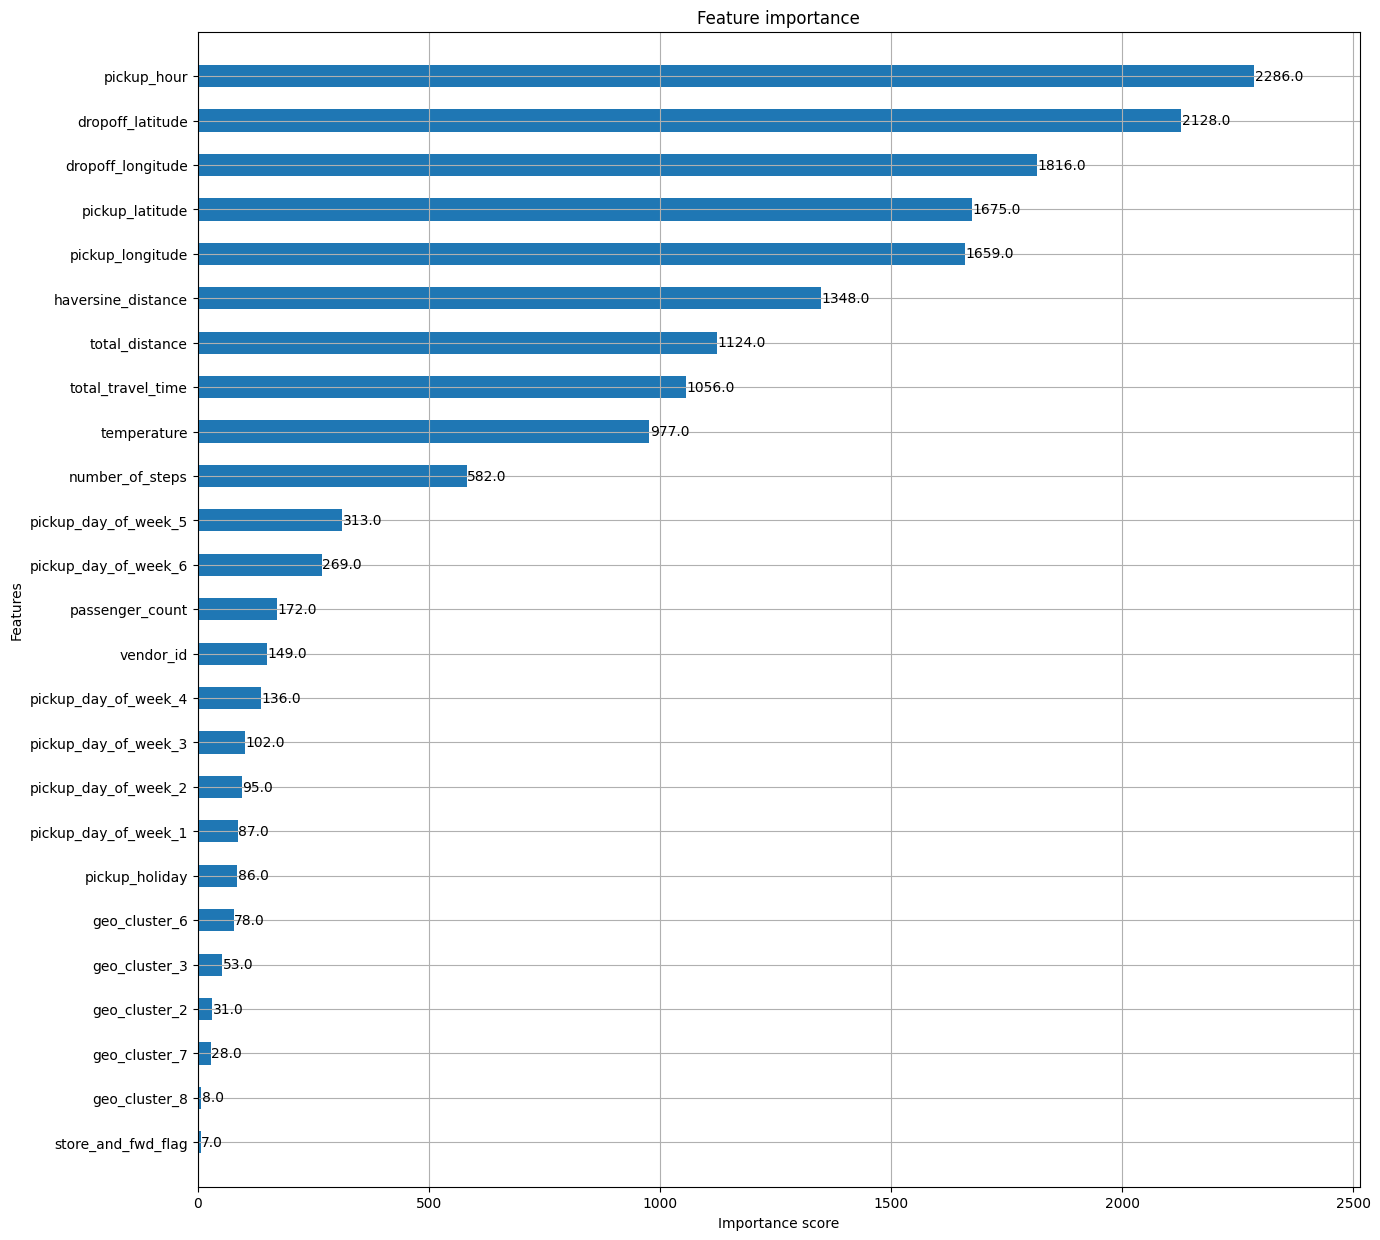

In [ ]:
fig, ax = plt.subplots(figsize = (15,15))
xgb.plot_importance(model, ax = ax, height=0.5)